## Library Imports and Configuration


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    make_scorer,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

f1_malignant_scorer = make_scorer(f1_score, pos_label=1)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## Data Loading and Initial Inspection


In [2]:
DATA_PATH = "breast_cancer_wisconsin_diagnostic.csv"

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,842517,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,84300903,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,84348301,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,84358402,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [3]:
print("Columns:")
display(pd.DataFrame({"column": df.columns}))

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values by column:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate row count:", df.duplicated().sum())

print("\nDiagnosis distribution:")
display(df["diagnosis"].value_counts().to_frame("count"))
display((df["diagnosis"].value_counts(normalize=True) * 100).round(2).to_frame("percentage"))


Columns:


,column
0,id
1,diagnosis
2,radius_mean
3,texture_mean
4,perimeter_mean
5,area_mean
6,smoothness_mean
7,compactness_mean
8,concavity_mean
9,concave_points_mean



Data types:


,dtype
id,int64
diagnosis,str
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave_points_mean,float64



Missing values by column:


,missing_values
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave_points_mean,0



Duplicate row count: 0

Diagnosis distribution:


,count
diagnosis,
B,357
M,212


,percentage
diagnosis,
B,62.7400
M,37.2600


## Data Preprocessing


In [4]:

df = df.drop(columns=["id"])
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})

feature_cols = [col for col in df.columns if col != "diagnosis"]
target_col   = "diagnosis"


null_counts = df.isna().sum()
total_null  = int(null_counts.sum())
print("=== Missing Value Check ===")
if total_null > 0:
    display(null_counts[null_counts > 0].to_frame("missing"))
else:
    print(f"No missing values detected across {df.shape[1]} columns.")
print(f"Total missing: {total_null}\n")


neg_counts = (df[feature_cols] < 0).sum()
print("=== Negative Value Check ===")
neg_found = neg_counts[neg_counts > 0]
if not neg_found.empty:
    display(neg_found.to_frame("n_negative"))
else:
    print("No negative values found in any of the 30 feature columns.")
print()


def cap_iqr(dataframe, columns):
    out = dataframe.copy()
    report = []
    for col in columns:
        q1, q3 = out[col].quantile([0.25, 0.75])
        iqr    = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n      = int(((out[col] < lo) | (out[col] > hi)).sum())
        out[col] = out[col].clip(lower=lo, upper=hi)
        if n > 0:
            report.append({"feature": col, "n_capped": n,
                           "lower_bound": round(lo, 4), "upper_bound": round(hi, 4)})
    return out, pd.DataFrame(report)

df, cap_report = cap_iqr(df, feature_cols)
print("=== IQR Outlier Capping ===")
print(f"{len(cap_report)} feature(s) had values capped outside 1.5Ã—IQR.")
if not cap_report.empty:
    display(cap_report)

print(f"\nFinal dataset shape: {df.shape}")
print(f"Features retained: {len(feature_cols)}")
display(df.head())
display(df[target_col].value_counts()
        .rename(index={0: "Benign", 1: "Malignant"})
        .to_frame("count"))


=== Missing Value Check ===
No missing values detected across 31 columns.
Total missing: 0

=== Negative Value Check ===
No negative values found in any of the 30 feature columns.

=== IQR Outlier Capping ===
29 feature(s) had values capped outside 1.5Ã—IQR.


,feature,n_capped,lower_bound,upper_bound
0,radius_mean,14,5.5800,21.9000
1,texture_mean,7,7.7250,30.2450
2,perimeter_mean,13,31.7750,147.4950
3,area_mean,25,-123.3000,1326.3000
4,smoothness_mean,6,0.0580,0.1337
5,compactness_mean,16,-0.0333,0.2286
6,concavity_mean,18,-0.1222,0.2824
7,concave_points_mean,10,-0.0602,0.1545
8,symmetry_mean,15,0.1112,0.2464
9,fractal_dimension_mean,15,0.0451,0.0787



Final dataset shape: (569, 31)
Features retained: 30


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2286,0.2824,0.1471,0.2419,0.0787,0.8487,0.9053,5.9835,86.2000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,1937.0500,0.1622,0.6270,0.7119,0.2654,0.4192,0.1189
1,1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1937.0500,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,1,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,86.2000,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,1,11.4200,20.3800,77.5800,386.1000,0.1337,0.2286,0.2414,0.1052,0.2464,0.0787,0.4956,1.1560,3.4450,27.2300,0.0091,0.0615,0.0566,0.0187,0.0360,0.0080,14.9100,26.5000,98.8700,567.7000,0.1901,0.6270,0.6869,0.2575,0.4192,0.1230
4,1,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,86.2000,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


,count
diagnosis,
Benign,357
Malignant,212


###  Geometric Feature Relationships



In [5]:
sample = df[["radius_mean", "perimeter_mean", "area_mean"]].head(6).copy()
sample["2_pi_r (expected perimeter)"] = (2 * np.pi * sample["radius_mean"]).round(2)
sample["pi_r2 (expected area)"]       = (np.pi * sample["radius_mean"] ** 2).round(2)
print("Geometric check â€” first 6 rows:")
display(sample)

corr_pairs = [
    ("radius_mean",    "area_mean"),
    ("radius_mean",    "perimeter_mean"),
    ("perimeter_mean", "area_mean"),
    ("radius_worst",   "area_worst"),
]
print("\nPearson correlations among geometrically related features:")
for a, b in corr_pairs:
    print(f"  {a} vs {b}: r = {df[a].corr(df[b]):.4f}")
print("\nConclusion: high inter-correlation is expected by geometry, not by target information.")


Geometric check â€” first 6 rows:


,radius_mean,perimeter_mean,area_mean,2_pi_r (expected perimeter),pi_r2 (expected area)
0,17.9900,122.8000,1001.0000,113.0300,1016.7500
1,20.5700,132.9000,1326.0000,129.2500,1329.2900
2,19.6900,130.0000,1203.0000,123.7200,1217.9800
3,11.4200,77.5800,386.1000,71.7500,409.7200
4,20.2900,135.1000,1297.0000,127.4900,1293.3400
5,12.4500,82.5700,477.1000,78.2300,486.9500



Pearson correlations among geometrically related features:
  radius_mean vs area_mean: r = 0.9939
  radius_mean vs perimeter_mean: r = 0.9977
  perimeter_mean vs area_mean: r = 0.9919
  radius_worst vs area_worst: r = 0.9932

Conclusion: high inter-correlation is expected by geometry, not by target information.


## Train / Test Split



In [6]:
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

split_check = pd.DataFrame({
    "train_count": y_train.value_counts().sort_index(),
    "train_percent": y_train.value_counts(normalize=True).sort_index() * 100,
    "test_count": y_test.value_counts().sort_index(),
    "test_percent": y_test.value_counts(normalize=True).sort_index() * 100,
}).rename(index={0: "Benign", 1: "Malignant"})

display(split_check.round(2))


Training shape: (455, 30)
Test shape: (114, 30)


,train_count,train_percent,test_count,test_percent
diagnosis,,,,
Benign,285,62.6400,72,63.1600
Malignant,170,37.3600,42,36.8400


## Feature Scaling



In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

display(X_train_scaled.describe().T[["mean", "std"]].head())


,mean,std
radius_mean,-0.0000,1.0011
texture_mean,-0.0000,1.0011
perimeter_mean,-0.0000,1.0011
area_mean,-0.0000,1.0011
smoothness_mean,-0.0000,1.0011


## Exploratory Data Analysis


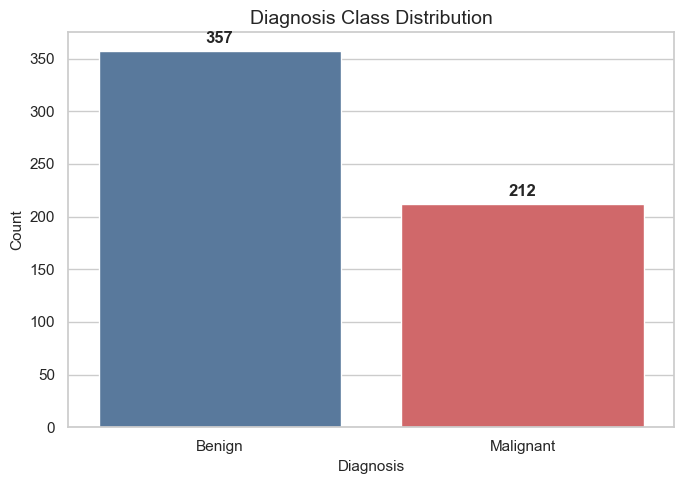

In [8]:
class_counts = df[target_col].map({0: "Benign", 1: "Malignant"}).value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#4E79A7", "#E15759"], ax=ax)
ax.set_title("Diagnosis Class Distribution")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("Count")

for i, value in enumerate(class_counts.values):
    ax.text(i, value + 5, str(value), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


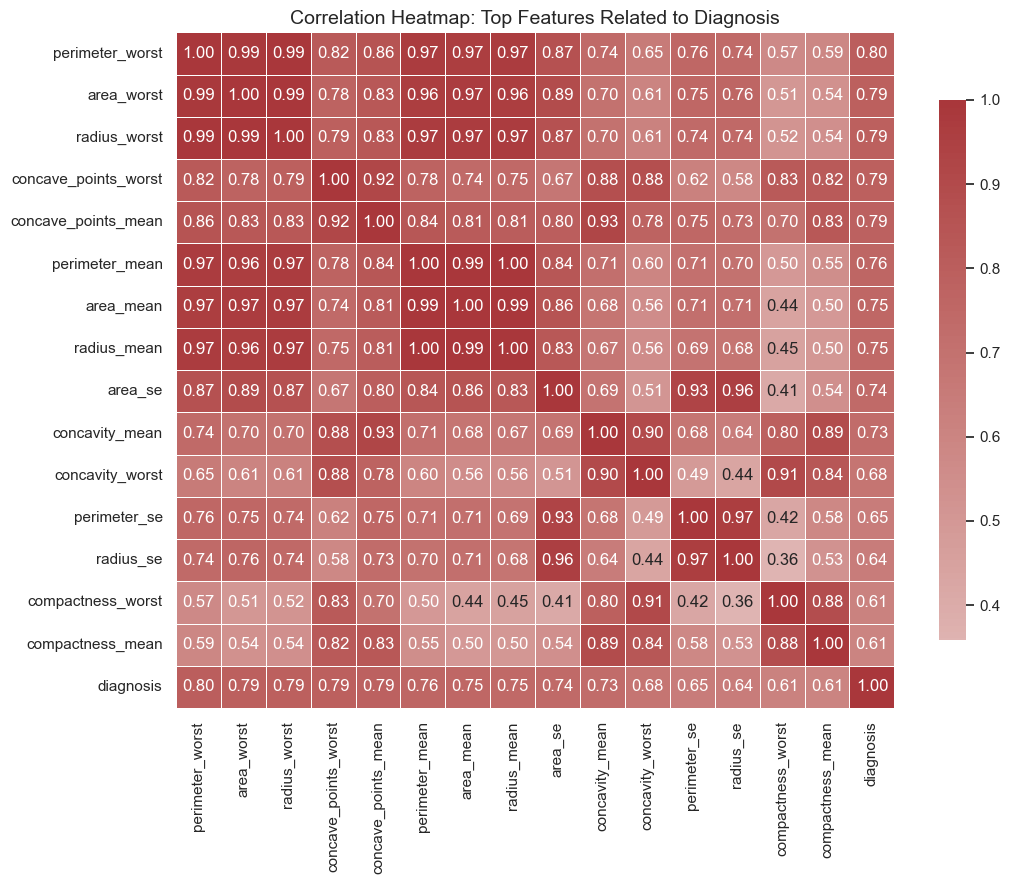

,pearson_correlation_with_diagnosis,abs_correlation
perimeter_worst,0.8006,0.8006
area_worst,0.7946,0.7946
radius_worst,0.7939,0.7939
concave_points_worst,0.7936,0.7936
concave_points_mean,0.7881,0.7881
perimeter_mean,0.7590,0.7590
area_mean,0.7528,0.7528
radius_mean,0.7452,0.7452
area_se,0.7391,0.7391
concavity_mean,0.7272,0.7272


In [9]:
corr_with_target = (
    df.corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_corr_features = corr_with_target.abs().head(15).index.tolist()

plt.figure(figsize=(11, 9))
sns.heatmap(
    df[top_corr_features + [target_col]].corr(),
    annot=True,
    cmap="vlag",
    center=0,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap: Top Features Related to Diagnosis")
plt.tight_layout()
plt.show()

display(
    corr_with_target.to_frame("pearson_correlation_with_diagnosis")
    .assign(abs_correlation=lambda x: x["pearson_correlation_with_diagnosis"].abs())
    .sort_values("abs_correlation", ascending=False)
    .head(15)
)


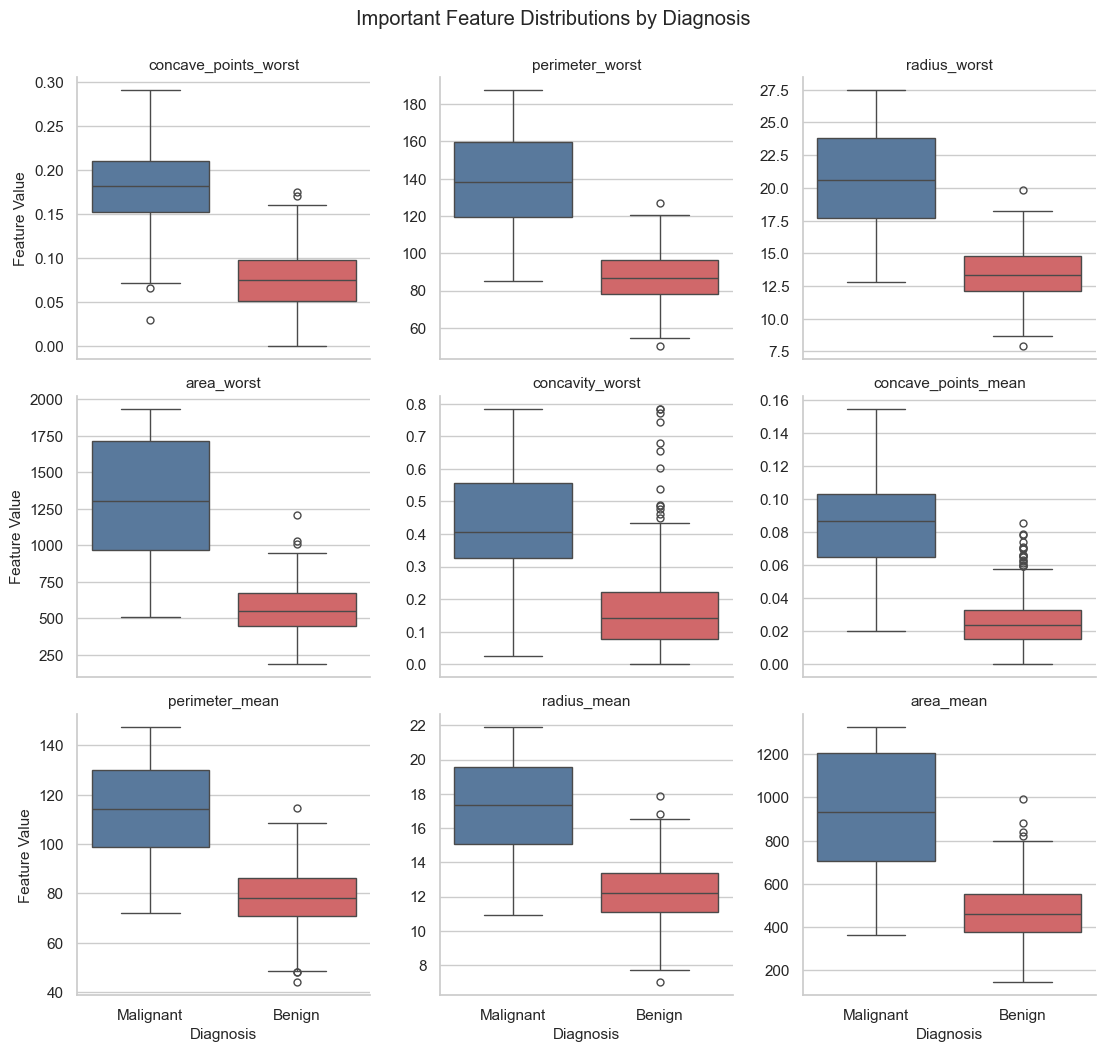

In [10]:
important_features = [
    "concave_points_worst",
    "perimeter_worst",
    "radius_worst",
    "area_worst",
    "concavity_worst",
    "concave_points_mean",
    "perimeter_mean",
    "radius_mean",
    "area_mean",
]

available_important_features = [f for f in important_features if f in df.columns]

plot_df = df[available_important_features + [target_col]].copy()
plot_df["diagnosis_label"] = plot_df[target_col].map({0: "Benign", 1: "Malignant"})
long_plot_df = plot_df.melt(
    id_vars=["diagnosis", "diagnosis_label"],
    value_vars=available_important_features,
    var_name="feature",
    value_name="value",
)

g = sns.catplot(
    data=long_plot_df,
    x="diagnosis_label",
    y="value",
    col="feature",
    col_wrap=3,
    kind="box",
    sharey=False,
    height=3.4,
    aspect=1.1,
    palette=["#4E79A7", "#E15759"],
)
g.set_axis_labels("Diagnosis", "Feature Value")
g.set_titles("{col_name}")
g.fig.suptitle("Important Feature Distributions by Diagnosis", y=1.03)
plt.show()


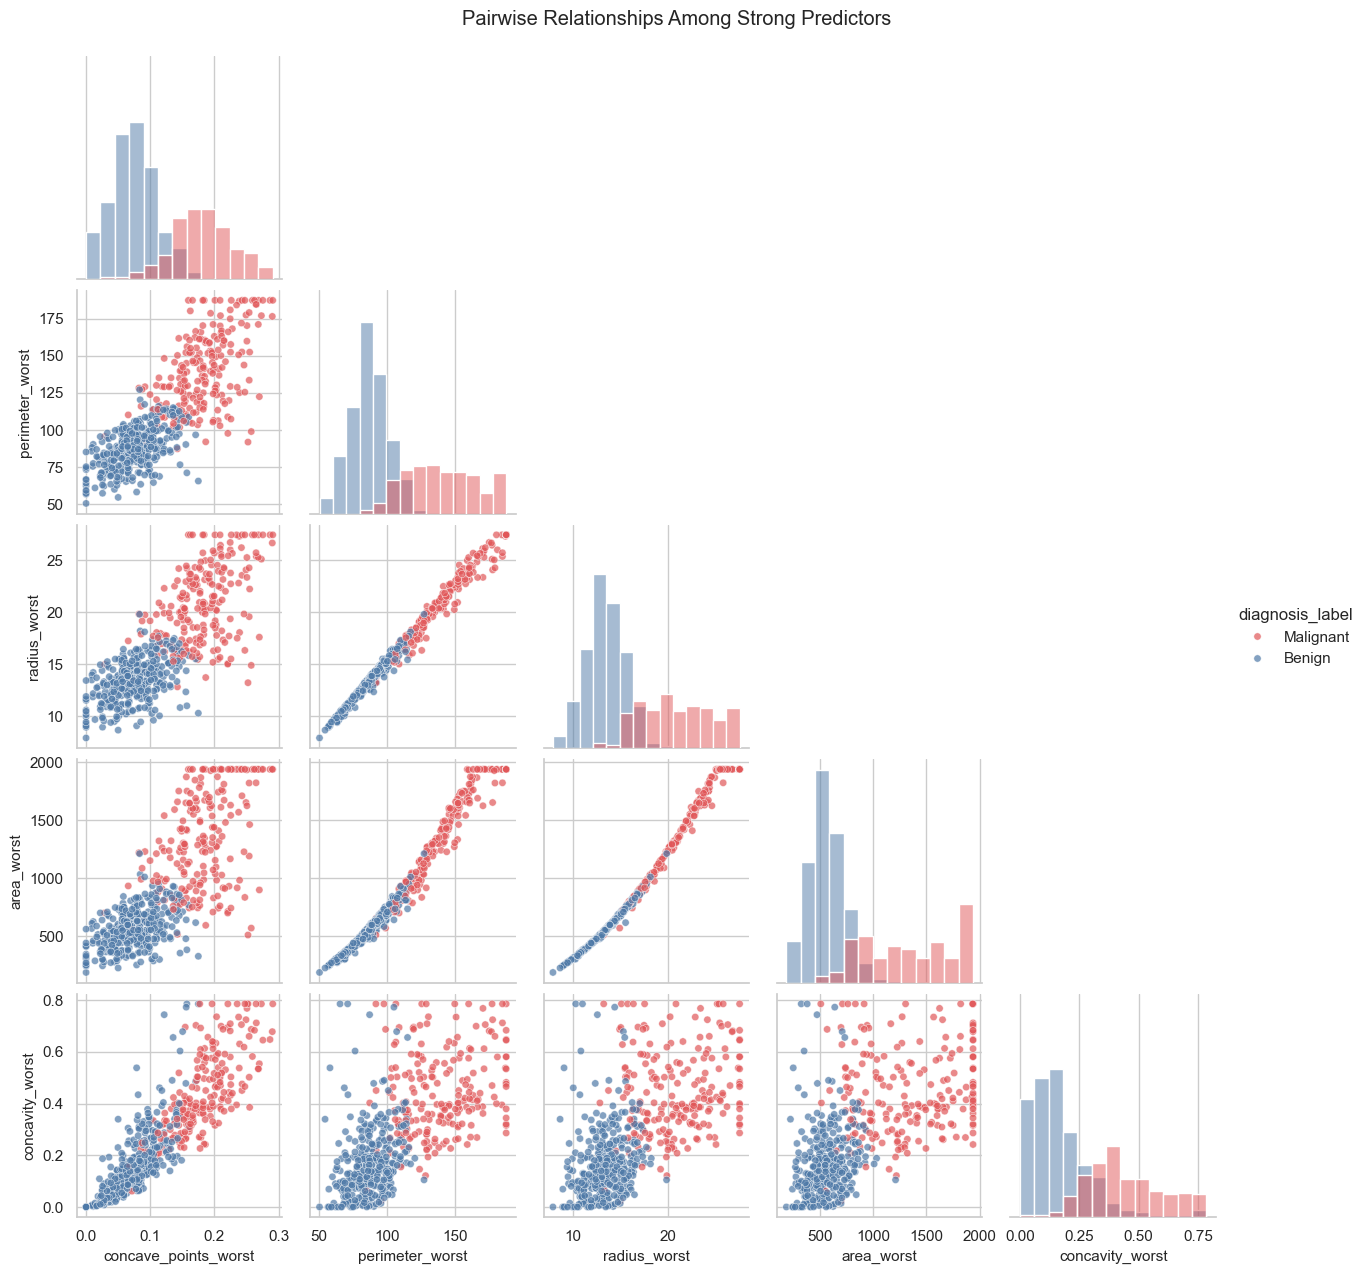

In [11]:
pair_features = [
    "concave_points_worst",
    "perimeter_worst",
    "radius_worst",
    "area_worst",
    "concavity_worst",
]

pairplot_df = df[pair_features + [target_col]].copy()
pairplot_df["diagnosis_label"] = pairplot_df[target_col].map({0: "Benign", 1: "Malignant"})

sns.pairplot(
    pairplot_df.drop(columns=[target_col]),
    hue="diagnosis_label",
    diag_kind="hist",
    corner=True,
    palette={"Benign": "#4E79A7", "Malignant": "#E15759"},
    plot_kws={"alpha": 0.7, "s": 28},
)
plt.suptitle("Pairwise Relationships Among Strong Predictors", y=1.02)
plt.show()


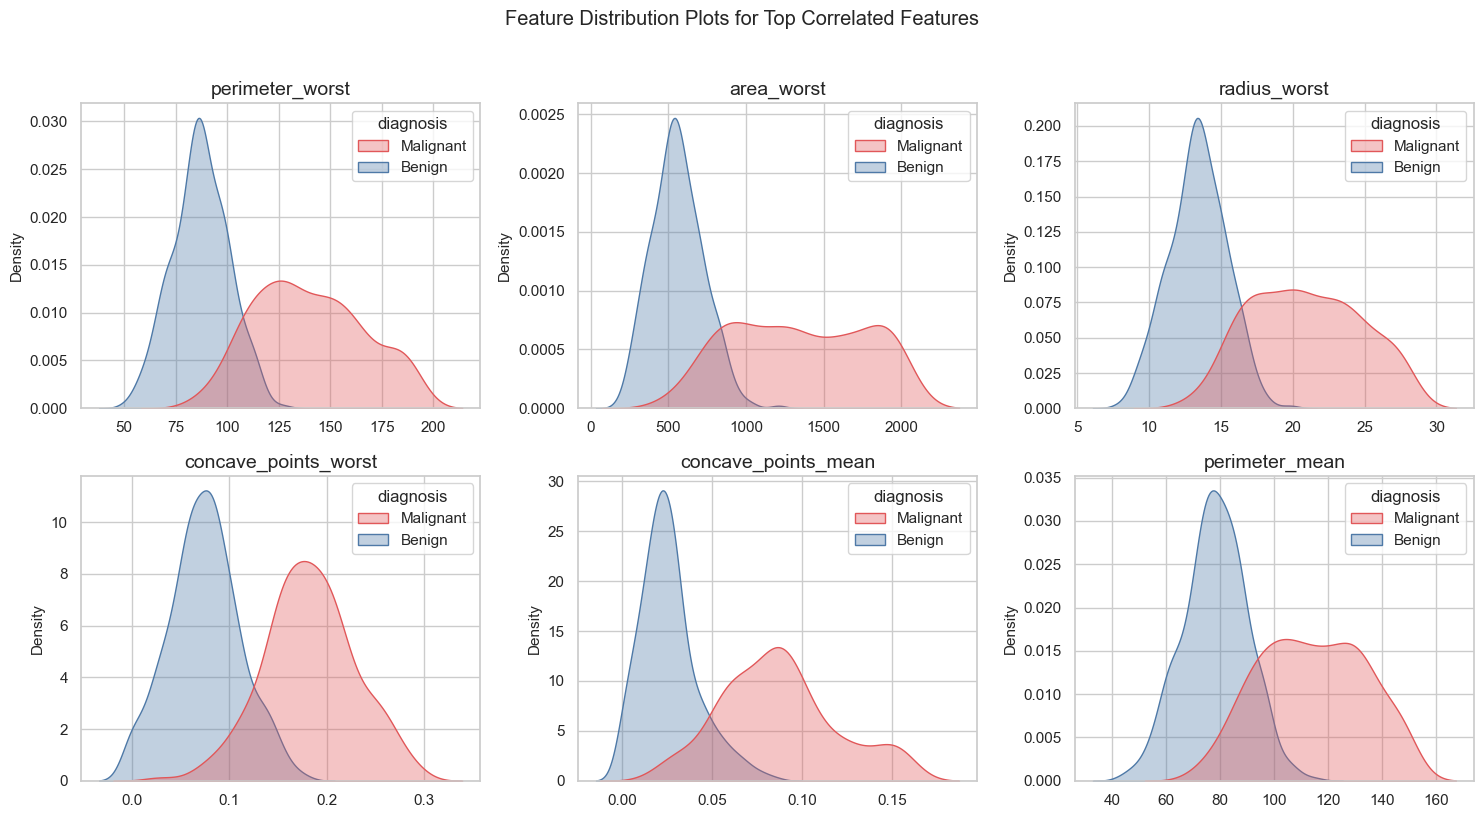

In [12]:
distribution_features = top_corr_features[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, feature in zip(axes, distribution_features):
    sns.kdeplot(
        data=df,
        x=feature,
        hue=df[target_col].map({0: "Benign", 1: "Malignant"}),
        fill=True,
        common_norm=False,
        alpha=0.35,
        palette={"Benign": "#4E79A7", "Malignant": "#E15759"},
        ax=ax,
    )
    ax.set_title(feature)
    ax.set_xlabel("")

plt.suptitle("Feature Distribution Plots for Top Correlated Features", y=1.02)
plt.tight_layout()
plt.show()


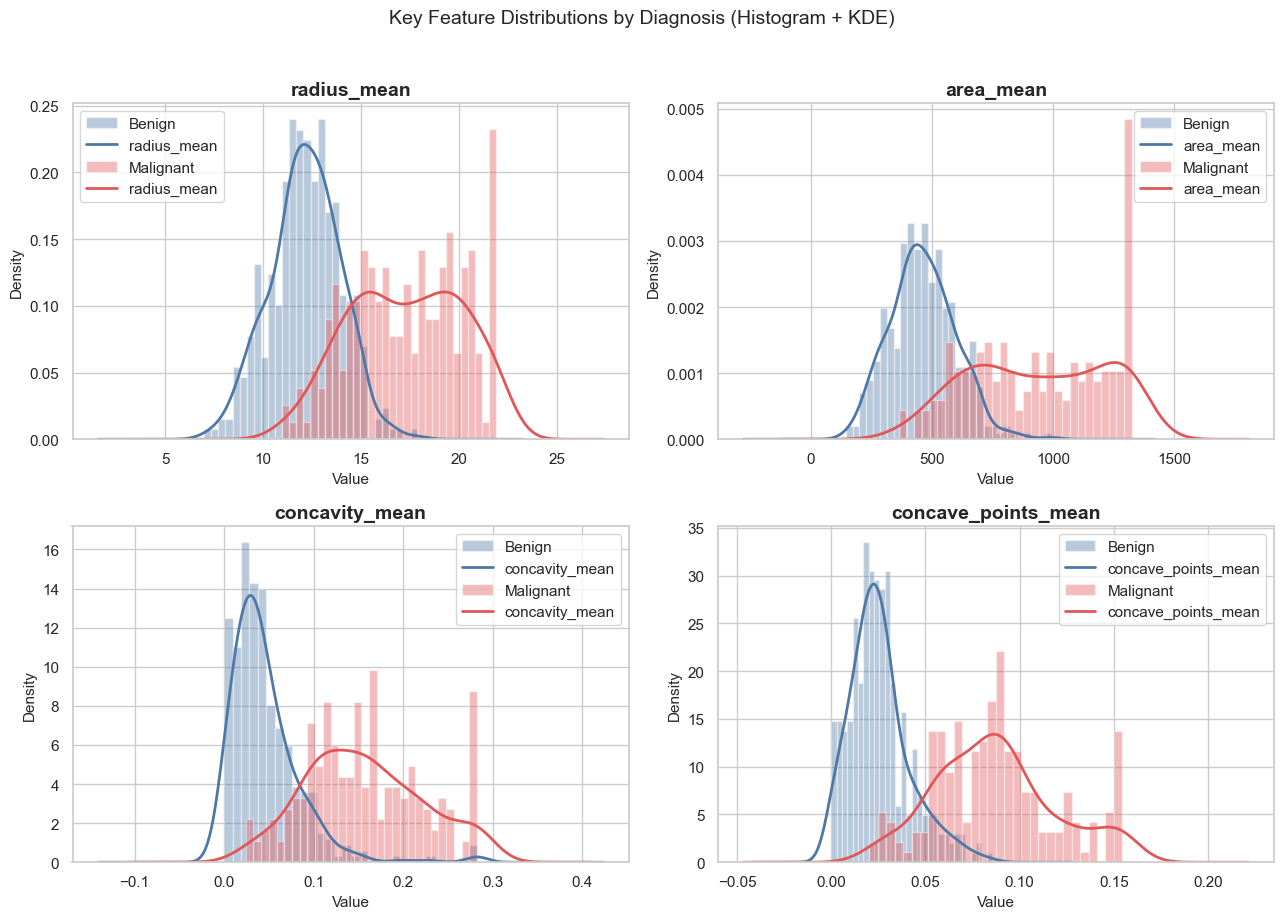

In [13]:
brief_features = ["radius_mean", "area_mean", "concavity_mean", "concave_points_mean"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.ravel()

for ax, feat in zip(axes, brief_features):
    for label, colour, name in [(0, "#4E79A7", "Benign"), (1, "#E15759", "Malignant")]:
        subset = df[df[target_col] == label][feat]
        ax.hist(subset, bins=30, alpha=0.40, color=colour, density=True, label=name)
        subset.plot.kde(ax=ax, color=colour, linewidth=2)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Key Feature Distributions by Diagnosis (Histogram + KDE)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


###  Mean Feature Values by Diagnosis


In [14]:
groupby_summary = (
    df.groupby(target_col)[feature_cols]
    .mean()
    .rename(index={0: "Benign (n=357)", 1: "Malignant (n=212)"})
)


print("Mean feature values by diagnosis class:")
display(groupby_summary.T.round(4))
pct_diff = (
    (groupby_summary.loc["Malignant (n=212)"] - groupby_summary.loc["Benign (n=357)"])
    / groupby_summary.loc["Benign (n=357)"]
    * 100
).abs().sort_values(ascending=False)

print("\nTop 10 features by absolute % difference (Malignant vs Benign):")
display(pct_diff.head(10).to_frame("abs_pct_difference").round(1))


Mean feature values by diagnosis class:


diagnosis,Benign (n=357),Malignant (n=212)
radius_mean,12.1465,17.2900
texture_mean,17.9034,21.5303
perimeter_mean,78.0754,114.2240
area_mean,462.7902,937.7844
smoothness_mean,0.0924,0.1028
compactness_mean,0.0801,0.1422
concavity_mean,0.0456,0.1566
concave_points_mean,0.0257,0.0870
symmetry_mean,0.1740,0.1920
fractal_dimension_mean,0.0626,0.0625



Top 10 features by absolute % difference (Malignant vs Benign):


,abs_pct_difference
concavity_mean,243.7000
concave_points_mean,238.3000
area_se,175.6000
concavity_worst,169.2000
concave_points_worst,144.8000
area_worst,139.7000
area_mean,102.6000
compactness_worst,98.8000
radius_se,95.2000
perimeter_se,93.8000


## Feature Selection and Feature Importance


,pearson_correlation,abs_pearson_correlation,random_forest_importance,average_rank
perimeter_worst,0.8006,0.8006,0.1360,1.0000
area_worst,0.7946,0.7946,0.1321,2.0000
concave_points_worst,0.7936,0.7936,0.1131,3.5000
radius_worst,0.7939,0.7939,0.0843,4.0000
concave_points_mean,0.7881,0.7881,0.1001,4.5000
perimeter_mean,0.7590,0.7590,0.0517,6.5000
radius_mean,0.7452,0.7452,0.0523,7.0000
area_mean,0.7528,0.7528,0.0378,8.5000
concavity_mean,0.7272,0.7272,0.0512,9.0000
area_se,0.7391,0.7391,0.0314,10.0000


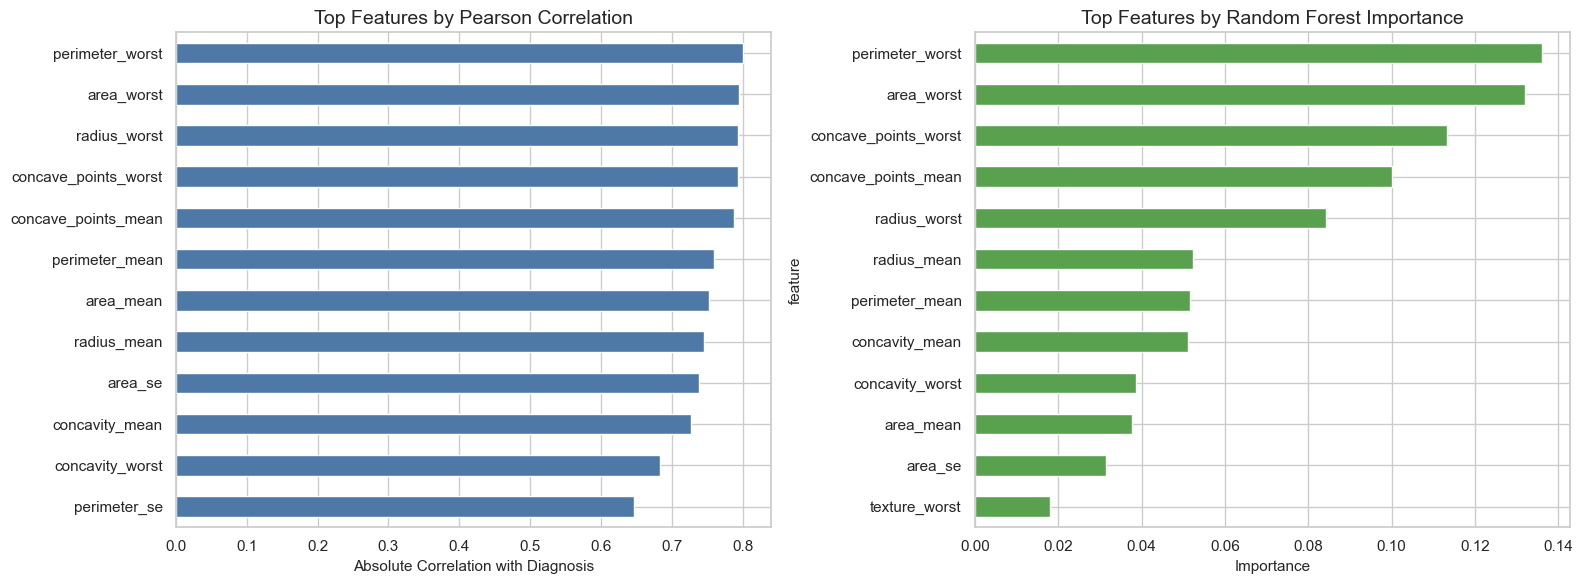

In [15]:
pearson_importance = (
    df.corr(numeric_only=True)[target_col]
    .drop(target_col)
    .to_frame("pearson_correlation")
)
pearson_importance["abs_pearson_correlation"] = pearson_importance["pearson_correlation"].abs()
pearson_importance = pearson_importance.sort_values("abs_pearson_correlation", ascending=False)

rf_for_importance = RandomForestClassifier(
    n_estimators=500,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    n_jobs=-1,
)
rf_for_importance.fit(X_train, y_train)

rf_importance = pd.DataFrame({
    "feature": feature_cols,
    "random_forest_importance": rf_for_importance.feature_importances_,
}).set_index("feature").sort_values("random_forest_importance", ascending=False)

combined_importance = pearson_importance.join(rf_importance)
combined_importance["average_rank"] = (
    combined_importance["abs_pearson_correlation"].rank(ascending=False)
    + combined_importance["random_forest_importance"].rank(ascending=False)
) / 2
combined_importance = combined_importance.sort_values("average_rank")

display(combined_importance.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pearson_importance.head(12).sort_values("abs_pearson_correlation").plot(
    kind="barh",
    y="abs_pearson_correlation",
    legend=False,
    color="#4E79A7",
    ax=axes[0],
)
axes[0].set_title("Top Features by Pearson Correlation")
axes[0].set_xlabel("Absolute Correlation with Diagnosis")

rf_importance.head(12).sort_values("random_forest_importance").plot(
    kind="barh",
    y="random_forest_importance",
    legend=False,
    color="#59A14F",
    ax=axes[1],
)
axes[1].set_title("Top Features by Random Forest Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


In [16]:
top_features = combined_importance.head(10).index.tolist()

print("Top combined features:")
for i, feature in enumerate(top_features, start=1):
    corr_value = combined_importance.loc[feature, "pearson_correlation"]
    rf_value = combined_importance.loc[feature, "random_forest_importance"]
    print(f"{i}. {feature}: correlation={corr_value:.3f}, RF importance={rf_value:.4f}")

print("\nInterpretation:")
print(
    "Features related to worst-case tumor size, perimeter, area, concavity, and concave points "
    "tend to rank highly. Larger and more irregular cell nuclei are strongly associated with malignant cases "
    "in this dataset, which is consistent with the diagnostic purpose of the measurements."
)


Top combined features:
1. perimeter_worst: correlation=0.801, RF importance=0.1360
2. area_worst: correlation=0.795, RF importance=0.1321
3. concave_points_worst: correlation=0.794, RF importance=0.1131
4. radius_worst: correlation=0.794, RF importance=0.0843
5. concave_points_mean: correlation=0.788, RF importance=0.1001
6. perimeter_mean: correlation=0.759, RF importance=0.0517
7. radius_mean: correlation=0.745, RF importance=0.0523
8. area_mean: correlation=0.753, RF importance=0.0378
9. concavity_mean: correlation=0.727, RF importance=0.0512
10. area_se: correlation=0.739, RF importance=0.0314

Interpretation:
Features related to worst-case tumor size, perimeter, area, concavity, and concave points tend to rank highly. Larger and more irregular cell nuclei are strongly associated with malignant cases in this dataset, which is consistent with the diagnostic purpose of the measurements.


## Model Building and Cross-Validation



In [17]:
baseline_models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, class_weight="balanced",
                                    random_state=RANDOM_STATE, solver="liblinear"),
        "scaled": True,
        "sample_weight": False,
        "pipeline": False,
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(n_neighbors=5),
        "scaled": True,
        "sample_weight": False,
        "pipeline": False,
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(max_depth=10, class_weight="balanced",
                                         random_state=RANDOM_STATE),
        "scaled": False,
        "sample_weight": False,
        "pipeline": False,
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                         random_state=RANDOM_STATE, n_jobs=-1),
        "scaled": False,
        "sample_weight": False,
        "pipeline": False,
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "scaled": False,
        "sample_weight": True,
        "pipeline": False,
    },
    "Support Vector Machine": {
        "model": SVC(kernel="rbf", probability=True, class_weight="balanced",
                     random_state=RANDOM_STATE),
        "scaled": True,
        "sample_weight": False,
        "pipeline": False,
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [18]:
def get_scores(model, X_eval):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_eval)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_eval)
    return model.predict(X_eval)


def cross_validate_model(name, config, X_data, y_data):
    f1_scores, roc_auc_scores = [], []

    for train_idx, valid_idx in cv.split(X_data, y_data):
        X_ft = X_data.iloc[train_idx]
        X_fv = X_data.iloc[valid_idx]
        y_ft = y_data.iloc[train_idx]
        y_fv = y_data.iloc[valid_idx]

        model = clone(config["model"])  

        if config["pipeline"]:
            model.fit(X_ft, y_ft)
            X_fv_used = X_fv
        elif config["scaled"]:
            fold_scaler    = StandardScaler()
            X_ft_used      = fold_scaler.fit_transform(X_ft)
            X_fv_used      = fold_scaler.transform(X_fv)
            if config["sample_weight"]:
                w = compute_sample_weight(class_weight="balanced", y=y_ft)
                model.fit(X_ft_used, y_ft, sample_weight=w)
            else:
                model.fit(X_ft_used, y_ft)
        else:
            if config["sample_weight"]:
                w = compute_sample_weight(class_weight="balanced", y=y_ft)
                model.fit(X_ft, y_ft, sample_weight=w)
            else:
                model.fit(X_ft, y_ft)
            X_fv_used = X_fv

        y_pred  = model.predict(X_fv_used)
        y_score = get_scores(model, X_fv_used)

        f1_scores.append(f1_score(y_fv, y_pred, pos_label=1))
        roc_auc_scores.append(roc_auc_score(y_fv, y_score))

    return {
        "model": name,
        "cv_f1_mean":     np.mean(f1_scores),
        "cv_f1_std":      np.std(f1_scores),
        "cv_roc_auc_mean": np.mean(roc_auc_scores),
        "cv_roc_auc_std":  np.std(roc_auc_scores),
    }


cv_results = [
    cross_validate_model(name, config, X_train, y_train)
    for name, config in baseline_models.items()
]

cv_results_df = pd.DataFrame(cv_results).sort_values(
    ["cv_roc_auc_mean", "cv_f1_mean"], ascending=False
)
display(cv_results_df)


,model,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
0,Logistic Regression,0.9647,0.0118,0.9963,0.0041
5,Support Vector Machine,0.9676,0.0110,0.9961,0.0035
4,Gradient Boosting,0.9442,0.0145,0.9905,0.0064
3,Random Forest,0.9523,0.0217,0.9882,0.0086
1,K-Nearest Neighbors,0.9572,0.0311,0.9869,0.0136
2,Decision Tree,0.9027,0.0311,0.9261,0.0264


## Baseline Model Evaluation on the Test Set



In [19]:
def evaluate_fitted_model(name, fitted_model, X_eval, y_true):
    y_pred = fitted_model.predict(X_eval)
    y_score = get_scores(fitted_model, X_eval)

    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_malignant": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_malignant": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_malignant": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "y_pred": y_pred,
        "y_score": y_score,
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(
            y_true,
            y_pred,
            target_names=["Benign", "Malignant"],
            zero_division=0,
        ),
    }


baseline_fitted = {}
baseline_evaluations = []

for name, config in baseline_models.items():
    model = config["model"]
    X_fit = X_train_scaled if config["scaled"] else X_train
    X_eval = X_test_scaled if config["scaled"] else X_test

    if config["sample_weight"]:
        weights = compute_sample_weight(class_weight="balanced", y=y_train)
        model.fit(X_fit, y_train, sample_weight=weights)
    else:
        model.fit(X_fit, y_train)

    baseline_fitted[name] = {"model": model, "scaled": config["scaled"]}
    baseline_evaluations.append(evaluate_fitted_model(name, model, X_eval, y_test))

baseline_metrics_df = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ["y_pred", "y_score", "confusion_matrix", "classification_report"]}
    for result in baseline_evaluations
]).sort_values(["roc_auc", "f1_malignant"], ascending=False)

display(baseline_metrics_df)


,model,accuracy,precision_malignant,recall_malignant,f1_malignant,roc_auc
4,Gradient Boosting,0.9649,1.0000,0.9048,0.9500,0.9970
0,Logistic Regression,0.9825,0.9762,0.9762,0.9762,0.9964
3,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9964
5,Support Vector Machine,0.9825,0.9762,0.9762,0.9762,0.9960
1,K-Nearest Neighbors,0.9386,0.9730,0.8571,0.9114,0.9813
2,Decision Tree,0.9035,0.8974,0.8333,0.8642,0.8889


In [20]:
for result in baseline_evaluations:
    print("=" * 80)
    print(result["model"])
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    print(result["confusion_matrix"])
    print("\nClassification report:")
    print(result["classification_report"])


Logistic Regression
Confusion matrix [[TN, FP], [FN, TP]]:
[[71  1]
 [ 1 41]]

Classification report:
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        72
   Malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

K-Nearest Neighbors
Confusion matrix [[TN, FP], [FN, TP]]:
[[71  1]
 [ 6 36]]

Classification report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

Decision Tree
Confusion matrix [[TN, FP], [FN, TP]]:
[[68  4]
 [ 7 35]]

Classification report:
              precision    recall  f1-score   

## Model Tuning with GridSearchCV


In [21]:
tuning_specs = {
    "Logistic Regression": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
        ]),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"],
            "model__solver": ["liblinear"],
            "model__class_weight": [None, "balanced"],
        },
        "fit_params": {},
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
        ]),
        "params": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 4, 8],
            "model__min_samples_split": [2, 5],
            "model__min_samples_leaf": [1, 2],
            "model__class_weight": [None, "balanced"],
        },
        "fit_params": {},
    },
    "Support Vector Machine": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, random_state=RANDOM_STATE)),
        ]),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", 0.01, 0.1],
            "model__kernel": ["rbf", "linear"],
            "model__class_weight": [None, "balanced"],
        },
        "fit_params": {},
    },
    "Gradient Boosting": {
        "pipeline": Pipeline([
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
        ]),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__subsample": [0.8, 1.0],
        },
        "fit_params": {
            "model__sample_weight": compute_sample_weight(class_weight="balanced", y=y_train),
        },
    },
}

scoring = {
    "f1": "f1",
    "roc_auc": "roc_auc",
    "recall": "recall",
}

tuned_models = {}
tuning_summary = []

for name, spec in tuning_specs.items():
    print(f"Tuning {name}...")
    grid = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["params"],
        scoring=scoring,
        refit="roc_auc",
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    grid.fit(X_train, y_train, **spec["fit_params"])
    tuned_models[name] = grid.best_estimator_
    tuning_summary.append({
        "model": name,
        "best_cv_roc_auc": grid.best_score_,
        "best_params": grid.best_params_,
        "mean_cv_f1_at_best_index": grid.cv_results_["mean_test_f1"][grid.best_index_],
        "mean_cv_recall_at_best_index": grid.cv_results_["mean_test_recall"][grid.best_index_],
    })

tuning_summary_df = pd.DataFrame(tuning_summary).sort_values("best_cv_roc_auc", ascending=False)
display(tuning_summary_df)


Tuning Logistic Regression...
Tuning Random Forest...
Tuning Support Vector Machine...
Tuning Gradient Boosting...


,model,best_cv_roc_auc,best_params,mean_cv_f1_at_best_index,mean_cv_recall_at_best_index
0,Logistic Regression,0.9965,"{'model__C': 1, 'model__class_weight': None, '...",0.9703,0.9647
2,Support Vector Machine,0.9964,"{'model__C': 1, 'model__class_weight': 'balanc...",0.9612,0.9588
3,Gradient Boosting,0.9935,"{'model__learning_rate': 0.1, 'model__max_dept...",0.9590,0.9588
1,Random Forest,0.9891,"{'model__class_weight': 'balanced', 'model__ma...",0.9406,0.9353


## Final Model Evaluation


In [22]:
final_models = {
    "Logistic Regression Tuned": tuned_models["Logistic Regression"],
    "K-Nearest Neighbors": baseline_fitted["K-Nearest Neighbors"]["model"],
    "Decision Tree": baseline_fitted["Decision Tree"]["model"],
    "Random Forest Tuned": tuned_models["Random Forest"],
    "Gradient Boosting Tuned": tuned_models["Gradient Boosting"],
    "Support Vector Machine Tuned": tuned_models["Support Vector Machine"],
}

final_evaluations = []

for name, model in final_models.items():
    if name == "K-Nearest Neighbors":
        X_eval = X_test_scaled
    elif name == "Decision Tree":
        X_eval = X_test
    else:
        X_eval = X_test

    final_evaluations.append(evaluate_fitted_model(name, model, X_eval, y_test))

final_metrics_df = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ["y_pred", "y_score", "confusion_matrix", "classification_report"]}
    for result in final_evaluations
])

display(final_metrics_df.sort_values(["roc_auc", "f1_malignant"], ascending=False))


,model,accuracy,precision_malignant,recall_malignant,f1_malignant,roc_auc
3,Random Forest Tuned,0.9737,1.0000,0.9286,0.9630,0.9974
0,Logistic Regression Tuned,0.9737,0.9756,0.9524,0.9639,0.9964
5,Support Vector Machine Tuned,0.9737,0.9756,0.9524,0.9639,0.9957
4,Gradient Boosting Tuned,0.9649,1.0000,0.9048,0.9500,0.9944
1,K-Nearest Neighbors,0.9386,0.9730,0.8571,0.9114,0.9813
2,Decision Tree,0.9035,0.8974,0.8333,0.8642,0.8889


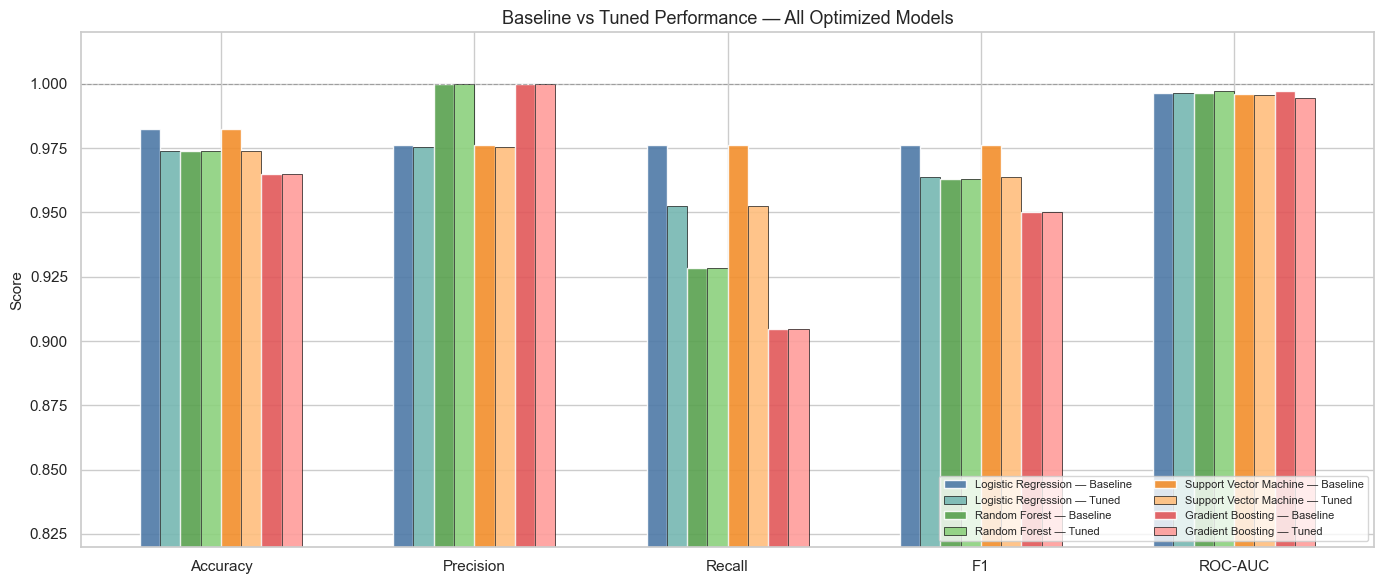

In [23]:
opt_names = ["Logistic Regression", "Random Forest", "Support Vector Machine", "Gradient Boosting"]
metrics_plot = ["accuracy", "precision_malignant", "recall_malignant", "f1_malignant", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

base_map  = {r["model"]: r for r in baseline_evaluations}
final_map = {r["model"]: r for r in final_evaluations}

bar_width = 0.08
x = np.arange(len(metrics_plot))
palette_base  = ["#4E79A7", "#59A14F", "#F28E2B", "#E15759"]
palette_tuned = ["#76B7B2", "#8CD17D", "#FFBE7D", "#FF9D9A"]

fig, ax = plt.subplots(figsize=(14, 6))
n = len(opt_names)

for i, name in enumerate(opt_names):
    tuned_key  = f"{name} Tuned"
    base_vals  = [base_map[name][m] for m in metrics_plot]
    tuned_vals = [final_map[tuned_key][m] for m in metrics_plot]
    offset = (i - n / 2 + 0.5) * 2 * bar_width
    ax.bar(x + offset - bar_width / 2, base_vals,  bar_width,
           label=f"{name} \u2014 Baseline", color=palette_base[i],  alpha=0.9)
    ax.bar(x + offset + bar_width / 2, tuned_vals, bar_width,
           label=f"{name} \u2014 Tuned",    color=palette_tuned[i], alpha=0.9,
           edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0.82, 1.02)
ax.set_ylabel("Score")
ax.set_title("Baseline vs Tuned Performance \u2014 All Optimized Models", fontsize=13)
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

In [24]:
for result in final_evaluations:
    print("=" * 80)
    print(result["model"])
    print("Confusion matrix [[TN, FP], [FN, TP]]:")
    print(result["confusion_matrix"])
    print("\nClassification report:")
    print(result["classification_report"])


Logistic Regression Tuned
Confusion matrix [[TN, FP], [FN, TP]]:
[[71  1]
 [ 2 40]]

Classification report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

K-Nearest Neighbors
Confusion matrix [[TN, FP], [FN, TP]]:
[[71  1]
 [ 6 36]]

Classification report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114

Decision Tree
Confusion matrix [[TN, FP], [FN, TP]]:
[[68  4]
 [ 7 35]]

Classification report:
              precision    recall  f1-sc

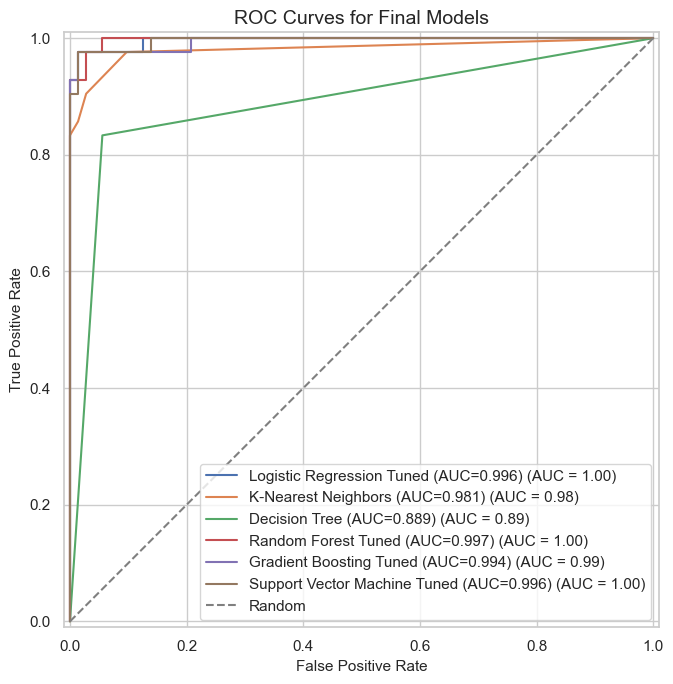

In [25]:
plt.figure(figsize=(9, 7))

for result in final_evaluations:
    RocCurveDisplay.from_predictions(
        y_test,
        result["y_score"],
        name=f"{result['model']} (AUC={result['roc_auc']:.3f})",
        ax=plt.gca(),
    )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("ROC Curves for Final Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Final Model Leaderboard


In [26]:
leaderboard = final_metrics_df.sort_values(["roc_auc", "f1_malignant"], ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1

display(leaderboard)

best_recall = final_metrics_df.loc[final_metrics_df["recall_malignant"].idxmax()]
best_f1 = final_metrics_df.loc[final_metrics_df["f1_malignant"].idxmax()]
best_roc_auc = final_metrics_df.loc[final_metrics_df["roc_auc"].idxmax()]

print(f"Best model for malignant recall: {best_recall['model']} ({best_recall['recall_malignant']:.3f})")
print(f"Best model for malignant F1-score: {best_f1['model']} ({best_f1['f1_malignant']:.3f})")
print(f"Best model for ROC-AUC: {best_roc_auc['model']} ({best_roc_auc['roc_auc']:.3f})")


,model,accuracy,precision_malignant,recall_malignant,f1_malignant,roc_auc
1,Random Forest Tuned,0.9737,1.0000,0.9286,0.9630,0.9974
2,Logistic Regression Tuned,0.9737,0.9756,0.9524,0.9639,0.9964
3,Support Vector Machine Tuned,0.9737,0.9756,0.9524,0.9639,0.9957
4,Gradient Boosting Tuned,0.9649,1.0000,0.9048,0.9500,0.9944
5,K-Nearest Neighbors,0.9386,0.9730,0.8571,0.9114,0.9813
6,Decision Tree,0.9035,0.8974,0.8333,0.8642,0.8889


Best model for malignant recall: Logistic Regression Tuned (0.952)
Best model for malignant F1-score: Logistic Regression Tuned (0.964)
Best model for ROC-AUC: Random Forest Tuned (0.997)
